<a href="https://colab.research.google.com/github/maahnumz/Machine-Learning-for-CyberSecurity/blob/main/homework_3_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=0c630e6a717e5b0dca45465000c301d65584a9a65a4d632b25cc6e61189d6a40
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


## 1. Data Loading

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
!tar -xf waf-urls.tar.xz
!ls
# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

sample_data  waf-urls.csv  waf-urls.tar.xz
Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [4]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    #raise NotImplementedError
    padded = start_symbol*(n-1) + text + end_symbol*n
    for i in range(len(padded)-n+1):
        yield padded[i:i+n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [5]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            # raise NotImplementedError
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        #raise NotImplementedError
        if count >= rare_threshold:
          idx = len(i2n)
          n2i[ngram] = idx
          i2n.append(ngram)
        else:
          n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 18262.57it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 142340.63it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [8]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            #idx = NotImplemented
            idx = n2i_mapping.get(ngram, unknown_idx)

            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            #raise NotImplementedError
            for prev_idx in prev_indices[-window_size:]:
              co_matrix[prev_idx, idx] = co_matrix.get((prev_idx, idx), 0) + 1
              co_matrix[idx, prev_idx] = co_matrix.get((idx, prev_idx), 0) + 1

            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        #raise NotImplementedError
        if row_sums[i,0] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i,0]

    return co_matrix

In [9]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 40663.17it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2124202.62it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [06:42<00:00, 90.36it/s] 


Normalizing...


100%|██████████| 2542234/2542234 [01:05<00:00, 38983.78it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [11]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
#embedding_svd = NotImplemented
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [20]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        #raise NotImplementedError
        url = url.ljust(padded_len, pad_symbol)

        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            #raise NotImplementedError
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [21]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [22]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        #self.embedding = NotImplemented
        self.embedding = nn.Embedding.from_pretrained(
          torch.tensor(embedding_weights, dtype=torch.float32),
          freeze=True
        )

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        #raise NotImplementedError
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)

        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)

        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        #raise NotImplementedError
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)

        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        #raise NotImplementedError
        x = self.embedding(x)
        x = x.permute(0,2,1)

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = torch.flatten(x,1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))

        return x

In [23]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [31]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        #raise NotImplementedError
        optimizer.zero_grad()

        y = y.unsqueeze(1).float()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1).float()

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)

    return total_loss / total, correct / total

In [32]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.9069, Val Acc=0.9156
Epoch 2: Train Acc=0.9133, Val Acc=0.9166
Epoch 3: Train Acc=0.9216, Val Acc=0.9266
Epoch 4: Train Acc=0.9245, Val Acc=0.9266
Epoch 5: Train Acc=0.9291, Val Acc=0.9302
Epoch 6: Train Acc=0.9307, Val Acc=0.9221
Epoch 7: Train Acc=0.9340, Val Acc=0.9400
Epoch 8: Train Acc=0.9380, Val Acc=0.9236
Epoch 9: Train Acc=0.9396, Val Acc=0.9287
Epoch 10: Train Acc=0.9398, Val Acc=0.9367


## 6. Evaluation

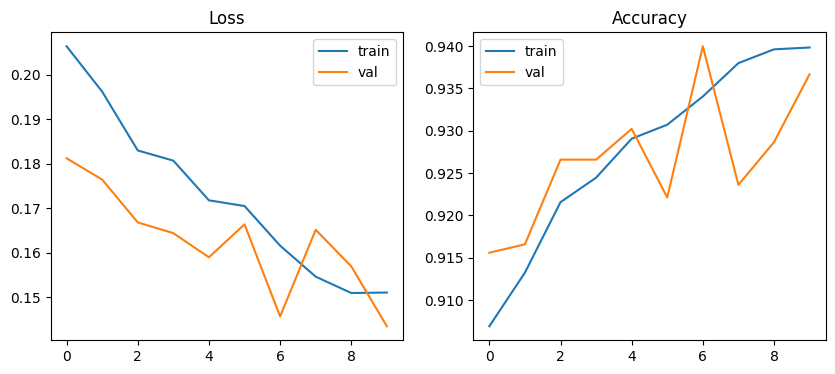

In [34]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
#raise NotImplementedError
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history['loss'], label="train")
plt.plot(history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['acc'], label="train")
plt.plot(history['val_acc'], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report
#raise NotImplementedError

test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=64)

preds = []
labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)

        preds.extend((out > 0.5).cpu().numpy().flatten())
        labels.extend(y.numpy())

print(confusion_matrix(labels, preds))
print(classification_report(labels, preds))

[[6525  618]
 [ 193 4774]]
              precision    recall  f1-score   support

         0.0       0.97      0.91      0.94      7143
         1.0       0.89      0.96      0.92      4967

    accuracy                           0.93     12110
   macro avg       0.93      0.94      0.93     12110
weighted avg       0.94      0.93      0.93     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)



```
`# This is formatted as code`
```

**Your Answer:**

Lower loss usually goes along with higher accuracy, but not always exactly. Loss measures how confident the model is in its predictions, while accuracy only checks whether the final prediction is right or wrong. So a model can have lower loss because it is becoming more confident, even if the number of correct predictions does not change much. In this assignment, I would expect the general trend to be that loss goes down as accuracy goes up, but they do not have to match perfectly at every epoch.



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

A very large window_size like 50 is probably not ideal here because it makes each n-gram co-occur with a lot of other n-grams that may not be closely related. That can add noise and make the co-occurrence matrix less meaningful. A smaller window usually captures more useful local patterns in the URL. For compression, SVD works well, but other options could also be used, like PCA, autoencoders, or even just using a smaller embedding dimension directly.

## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`